# Sleep Apnea Detection — v3 (SE-ResNet, no mixup)
## Strategy: v1 (73.6%) base + only proven additions:
- ✅ **SE blocks** added to ResNet (channel attention)
- ✅ **Optimal threshold tuning** (Youden's J on validation)
- ✅ **Test-Time Augmentation** (5 augmented copies, averaged)
- ✅ **Train longer** (40 epochs with patience)
- ❌ NO mixup (hurt v2's performance)
- ❌ NO extra res_block (unnecessary capacity)

**Target: 76–78% test accuracy**

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

2026-05-06 19:18:32.899181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778095113.336385      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778095113.450192      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778095114.419477      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778095114.419540      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778095114.419543      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_DIR    = '/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF'
OUTPUT_DIR  = '/kaggle/working'
MODEL_DIR   = os.path.join(OUTPUT_DIR, 'models')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')

SR         = 16000
N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512
MAX_SEGS   = 30          # back to v1 setting (most files have ≤30 anyway)
BATCH_SIZE = 64
EPOCHS     = 40          # slightly more than v1's 30
INITIAL_LR = 3e-4

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Config ready')

Config ready


In [3]:
# Load and process data (same as v1)
patient_folders = sorted([
    f for f in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, f))
])
print('Patients:', len(patient_folders))

all_specs  = []
all_labels = []
all_pids   = []

np.random.seed(42)

for pid in tqdm(patient_folders, desc='Processing'):
    folder = os.path.join(DATA_DIR, pid)

    for pattern, label in [('*_ap.npy', 1), ('*_nap.npy', 0)]:
        files = glob.glob(os.path.join(folder, pattern))
        for fpath in files:
            batch = np.load(fpath)
            n_total = batch.shape[0]

            if n_total > MAX_SEGS:
                indices = np.random.choice(n_total, MAX_SEGS, replace=False)
            else:
                indices = np.arange(n_total)

            for i in indices:
                audio = batch[i].astype(np.float32)
                audio = audio / (np.max(np.abs(audio)) + 1e-8)

                mel = librosa.feature.melspectrogram(
                    y=audio, sr=SR, n_fft=N_FFT,
                    hop_length=HOP_LENGTH, n_mels=N_MELS
                )
                mel_db = librosa.power_to_db(mel, ref=np.max)
                mel_min = mel_db.min()
                mel_max = mel_db.max()
                if mel_max - mel_min > 0:
                    mel_norm = (mel_db - mel_min) / (mel_max - mel_min)
                else:
                    mel_norm = np.zeros_like(mel_db)

                all_specs.append(mel_norm.astype(np.float32))
                all_labels.append(label)
                all_pids.append(pid)

total = len(all_specs)
apnea = sum(all_labels)
normal = total - apnea
print('Total:', total, '| Shape:', all_specs[0].shape)
print('Apnea:', apnea, '| Normal:', normal)

Patients: 192


Processing:   0%|          | 0/192 [00:00<?, ?it/s]

Total: 11349 | Shape: (128, 313)
Apnea: 5738 | Normal: 5611


In [4]:
# Patient-level stratified split (same as v1)
specs_arr  = np.array(all_specs)
labels_arr = np.array(all_labels)
pids_arr   = np.array(all_pids)

unique_pids = np.array(sorted(set(all_pids)))
pid_labels = np.array([labels_arr[pids_arr == p].mean() > 0.5 for p in unique_pids]).astype(int)

train_pids, temp_pids = train_test_split(
    unique_pids, test_size=0.30, random_state=42, stratify=pid_labels
)
temp_labels = np.array([labels_arr[pids_arr == p].mean() > 0.5 for p in temp_pids]).astype(int)

try:
    val_pids, test_pids = train_test_split(
        temp_pids, test_size=0.50, random_state=42, stratify=temp_labels
    )
except ValueError:
    val_pids, test_pids = train_test_split(temp_pids, test_size=0.50, random_state=42)

train_pids = set(train_pids)
val_pids   = set(val_pids)
test_pids  = set(test_pids)

train_mask = np.array([p in train_pids for p in all_pids])
val_mask   = np.array([p in val_pids   for p in all_pids])
test_mask  = np.array([p in test_pids  for p in all_pids])

X_train = specs_arr[train_mask][..., np.newaxis]
y_train = labels_arr[train_mask]
X_val   = specs_arr[val_mask][..., np.newaxis]
y_val   = labels_arr[val_mask]
X_test  = specs_arr[test_mask][..., np.newaxis]
y_test  = labels_arr[test_mask]

print('Train:', X_train.shape, '| ratio:', round(y_train.mean(), 2))
print('Val  :', X_val.shape, '| ratio:', round(y_val.mean(), 2))
print('Test :', X_test.shape, '| ratio:', round(y_test.mean(), 2))

Train: (7926, 128, 313, 1) | ratio: 0.51
Val  : (1705, 128, 313, 1) | ratio: 0.5
Test : (1718, 128, 313, 1) | ratio: 0.51


In [5]:
# ════════════════════════════════════════════════════
# AUGMENTATION — same as v1, NO mixup
# ════════════════════════════════════════════════════
@tf.function
def augment_fn(x, y):
    shape = tf.shape(x)
    h = shape[0]
    w = shape[1]
    if tf.random.uniform([]) > 0.5:
        f = tf.random.uniform([], 5, tf.minimum(20, h - 1), dtype=tf.int32)
        f0 = tf.random.uniform([], 0, h - f, dtype=tf.int32)
        indices = tf.range(h)
        mask = tf.cast(~((indices >= f0) & (indices < f0 + f)), tf.float32)
        mask = tf.reshape(mask, [h, 1, 1])
        x = x * mask
    if tf.random.uniform([]) > 0.5:
        t = tf.random.uniform([], 5, tf.minimum(20, w - 1), dtype=tf.int32)
        t0 = tf.random.uniform([], 0, w - t, dtype=tf.int32)
        indices = tf.range(w)
        mask = tf.cast(~((indices >= t0) & (indices < t0 + t)), tf.float32)
        mask = tf.reshape(mask, [1, w, 1])
        x = x * mask
    if tf.random.uniform([]) > 0.5:
        gain = tf.random.uniform([], 0.8, 1.2)
        x = tf.clip_by_value(x * gain, 0.0, 1.0)
    return x, y

def make_dataset(X, y, batch_size, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, BATCH_SIZE, shuffle=True, augment=True)
val_ds   = make_dataset(X_val, y_val, BATCH_SIZE, shuffle=False, augment=False)

for xb, yb in train_ds.take(1):
    print('Batch:', xb.shape, '✅')

I0000 00:00:1778095595.707502      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778095595.715537      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch: (64, 128, 313, 1) ✅


In [6]:
# ════════════════════════════════════════════════════
# SE-ResNet — v1 architecture (3 blocks) + SE attention
# ════════════════════════════════════════════════════

def se_block(x, ratio=8):
    """Squeeze-and-Excitation: channel-wise attention"""
    filters = x.shape[-1]
    se = keras.layers.GlobalAveragePooling2D()(x)
    se = keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = keras.layers.Dense(filters, activation='sigmoid')(se)
    se = keras.layers.Reshape((1, 1, filters))(se)
    return keras.layers.Multiply()([x, se])

def res_block(x, filters, stride=1, use_se=True):
    shortcut = x
    x = keras.layers.Conv2D(filters, (3,3), strides=stride, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Conv2D(filters, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    if use_se:
        x = se_block(x)
    if stride > 1 or shortcut.shape[-1] != filters:
        shortcut = keras.layers.Conv2D(filters, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
    x = keras.layers.Add()([x, shortcut])
    x = keras.layers.ReLU()(x)
    return x

def build_resnet():
    inputs = keras.Input(shape=(128, 313, 1))

    x = keras.layers.Conv2D(32, (7,7), strides=2, padding='same')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPooling2D((3,3), strides=2, padding='same')(x)

    # 3 blocks (matching v1) but with SE attention added
    x = res_block(x, 32)
    x = res_block(x, 64, stride=2)
    x = res_block(x, 128, stride=2)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.5)(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='OSA_SE_ResNet_v3')

model = build_resnet()
print('Params:', model.count_params())

Params: 324029


In [7]:
# ════════════════════════════════════════════════════
# TRAIN — class_weight is BACK (no mixup, so it works)
# ════════════════════════════════════════════════════
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print('Class weights:', class_weight_dict)

def cosine_lr(epoch, lr):
    return INITIAL_LR * 0.5 * (1 + np.cos(np.pi * epoch / EPOCHS))

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=INITIAL_LR, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.LearningRateScheduler(cosine_lr, verbose=0),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=12,
            restore_best_weights=True, verbose=1, mode='max'
        ),
        keras.callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, 'best_model_v3.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1, mode='max'
        ),
    ],
    verbose=1,
)
print('Training complete!')

Class weights: {0: np.float64(1.0132958322679622), 1: np.float64(0.9870485678704857)}
Epoch 1/40


I0000 00:00:1778095611.009220      70 service.cc:152] XLA service 0x7fe200005e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778095611.009274      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778095611.009280      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778095612.650311      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-06 19:26:56.443932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 19:26:56.589221: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/124 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.5625 - auc: 0.5867 - loss: 0.6833  

I0000 00:00:1778095623.028343      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5595 - auc: 0.5901 - loss: 0.6934

2026-05-06 19:27:10.094215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 19:27:10.238382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5596 - auc: 0.5903 - loss: 0.6933
Epoch 1: val_accuracy improved from -inf to 0.49971, saving model to /kaggle/working/models/best_model_v3.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 140ms/step - accuracy: 0.5597 - auc: 0.5904 - loss: 0.6933 - val_accuracy: 0.4997 - val_auc: 0.4981 - val_loss: 0.7010 - learning_rate: 3.0000e-04
Epoch 2/40
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6052 - auc: 0.6322 - loss: 0.6682
Epoch 2: val_accuracy did not improve from 0.49971
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6052 - auc: 0.6323 - loss: 0.6682 - val_accuracy: 0.4997 - val_auc: 0.6658 - val_loss: 0.7644 - learning_rate: 2.9954e-04
Epoch 3/40
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6323 - auc: 0.6796 - loss: 0.6412
Epoch 3: val_accuracy improved from 0.49971 to 0.58358, saving model to /kaggle/working/models/best_model_v3.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6322 - auc: 0.6

In [8]:
# ════════════════════════════════════════════════════
# EVALUATION: Threshold tuning + TTA
# ════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Step 1: Find optimal threshold on validation set
val_probs = model.predict(X_val, batch_size=64, verbose=0).flatten()
fpr_val, tpr_val, thresholds = roc_curve(y_val, val_probs)
youden_j = tpr_val - fpr_val
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal threshold from val: {optimal_threshold:.4f}')
print(f'Val AUC: {roc_auc_score(y_val, val_probs):.4f}')

# Step 2: Test-Time Augmentation
def tta_predict(model, X, n_aug=5, batch_size=64):
    preds = [model.predict(X, batch_size=batch_size, verbose=0).flatten()]
    for _ in range(n_aug):
        X_aug = X.copy()
        gain = np.random.uniform(0.85, 1.15, size=(X_aug.shape[0], 1, 1, 1)).astype(np.float32)
        X_aug = np.clip(X_aug * gain, 0.0, 1.0).astype(np.float32)
        shift = np.random.randint(-15, 15)
        X_aug = np.roll(X_aug, shift, axis=2)
        preds.append(model.predict(X_aug, batch_size=batch_size, verbose=0).flatten())
    return np.mean(preds, axis=0)

print('\nRunning TTA on test set...')
y_pred_prob_tta = tta_predict(model, X_test, n_aug=5)
y_pred_prob_std = model.predict(X_test, batch_size=64, verbose=0).flatten()

# Step 3: Compare strategies
print('\n' + '='*60)
print('STRATEGY COMPARISON')
print('='*60)

strategies = [
    ('Standard (threshold=0.5)',      y_pred_prob_std,  0.5),
    ('Standard + optimal threshold',  y_pred_prob_std,  optimal_threshold),
    ('TTA + threshold=0.5',           y_pred_prob_tta,  0.5),
    ('TTA + optimal threshold',       y_pred_prob_tta,  optimal_threshold),
]

best_acc = 0
best_name = ''
best_probs = None
best_thresh = 0.5
for name, probs, thresh in strategies:
    y_pred = (probs >= thresh).astype(int)
    acc = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, probs)
    print(f'{name:35s} | Acc: {acc:.4f} | AUC: {auc:.4f}')
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_probs = probs
        best_thresh = thresh

# Step 4: Detailed report on BEST strategy
y_pred_final = (best_probs >= best_thresh).astype(int)
final_acc = (y_pred_final == y_test).mean()
final_auc = roc_auc_score(y_test, best_probs)

print('\n' + '='*60)
print(f'BEST STRATEGY: {best_name}')
print('='*60)
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Apnea'], digits=3))
print(f'Test Accuracy : {final_acc:.4f}')
print(f'ROC-AUC       : {final_auc:.4f}')

Optimal threshold from val: 0.5915
Val AUC: 0.7991

Running TTA on test set...

STRATEGY COMPARISON
Standard (threshold=0.5)            | Acc: 0.7631 | AUC: 0.8180
Standard + optimal threshold        | Acc: 0.7421 | AUC: 0.8180
TTA + threshold=0.5                 | Acc: 0.7445 | AUC: 0.8135
TTA + optimal threshold             | Acc: 0.7357 | AUC: 0.8135

BEST STRATEGY: Standard (threshold=0.5)
              precision    recall  f1-score   support

      Normal      0.828     0.657     0.732       848
       Apnea      0.722     0.867     0.787       870

    accuracy                          0.763      1718
   macro avg      0.775     0.762     0.760      1718
weighted avg      0.774     0.763     0.760      1718

Test Accuracy : 0.7631
ROC-AUC       : 0.8180


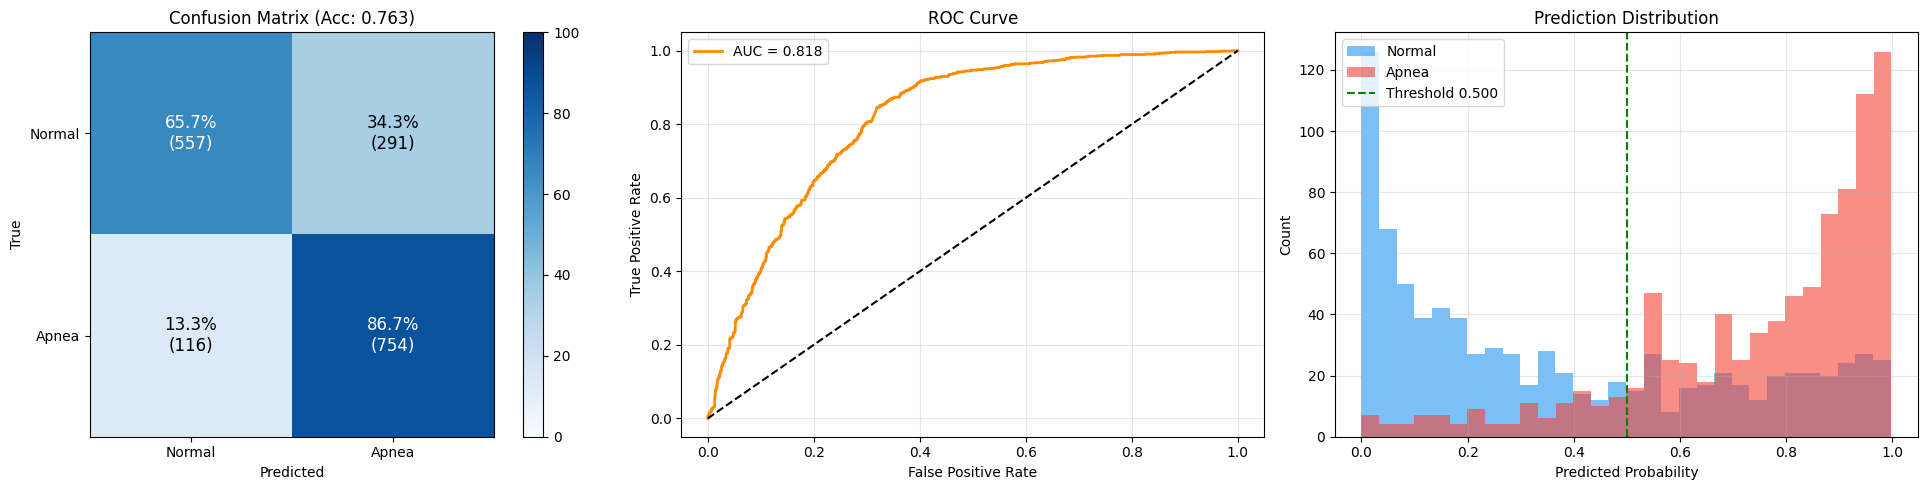

In [9]:
# ════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

im = axes[0].imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(round(cm_pct[i,j], 1)) + '%\n(' + str(cm[i,j]) + ')',
                     ha='center', va='center',
                     color='white' if cm_pct[i,j] > 50 else 'black', fontsize=12)
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'Apnea'])
axes[0].set_yticklabels(['Normal', 'Apnea'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix (Acc: {final_acc:.3f})')
plt.colorbar(im, ax=axes[0])

fpr, tpr, _ = roc_curve(y_test, best_probs)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC = {final_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(best_probs[y_test==0], bins=30, alpha=0.6, label='Normal', color='#2196F3')
axes[2].hist(best_probs[y_test==1], bins=30, alpha=0.6, label='Apnea', color='#F44336')
axes[2].axvline(best_thresh, color='green', ls='--', label=f'Threshold {best_thresh:.3f}')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Prediction Distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'evaluation_v3.png'), dpi=150)
plt.show()

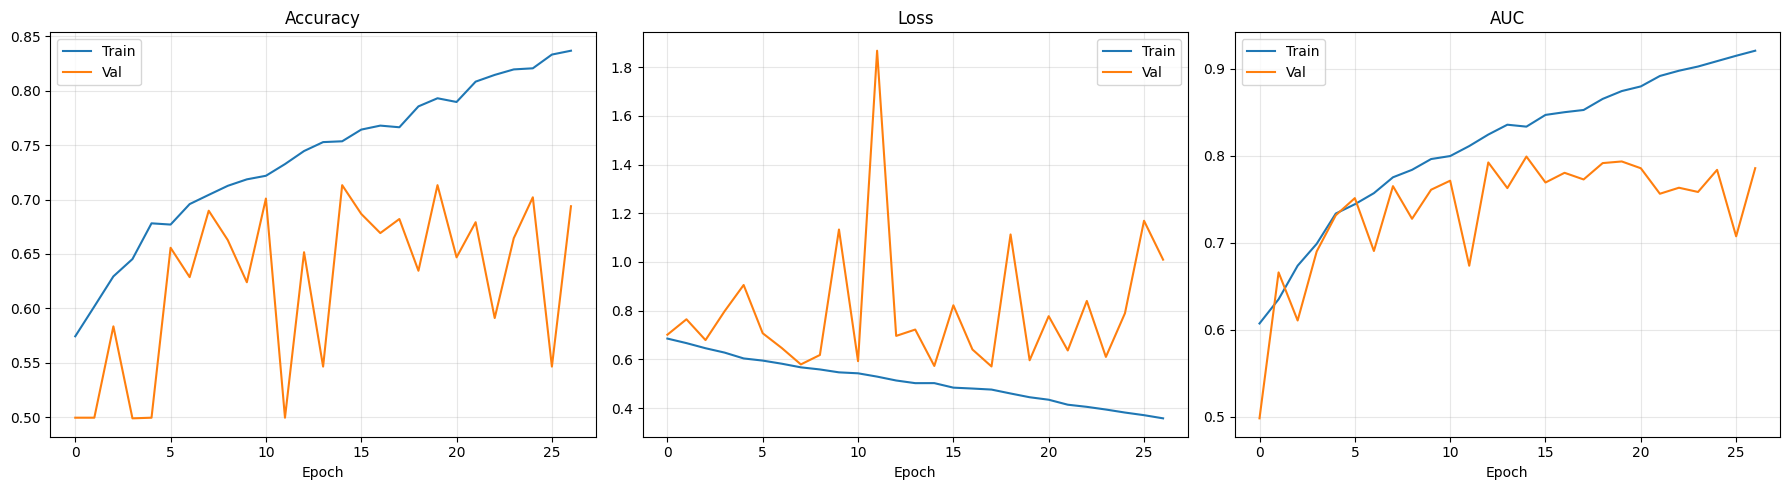


DONE
Final Test Accuracy : 0.7631
Final ROC-AUC       : 0.8180
Best Strategy       : Standard (threshold=0.5)


In [10]:
# ════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════
model.save(os.path.join(MODEL_DIR, 'final_model_v3.keras'))
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_v3.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(hist_df['accuracy'], label='Train')
axes[0].plot(hist_df['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_df['loss'], label='Train')
axes[1].plot(hist_df['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

if 'auc' in hist_df.columns:
    axes[2].plot(hist_df['auc'], label='Train')
    axes[2].plot(hist_df['val_auc'], label='Val')
    axes[2].set_title('AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_history_v3.png'), dpi=150)
plt.show()

print('\n' + '='*60)
print('DONE')
print('='*60)
print(f'Final Test Accuracy : {final_acc:.4f}')
print(f'Final ROC-AUC       : {final_auc:.4f}')
print(f'Best Strategy       : {best_name}')